# 基于因子的市场状态识别

**第 1 章 · §1.4 市场状态：变化是唯一的不变**

**Docker 镜像**：`ml4t`

## 目的

演示使用高斯混合模型（GMM）对行业指数收益率进行无监督市场状态识别。

## 学习目标

- 将 BGMM/GMM 聚类应用于因子收益率时间序列。
- 使用 BIC、AIC 和轮廓系数评估聚类数量。
- 可视化带有历史事件标注的状态时间线。
- 比较不同状态下因子的表现。

## 书籍参考

第 1 章第 1.4 节"市场状态：变化是唯一的不变"——即先于 `macro_regimes.py` 中宏观状态视角的风格状态视角。

## 前置要求

- 熟悉月度收益率序列和 StandardScaler 式预处理。
- 对混合模型和信息准则有概念性了解。

## 背景

灵感来自 [Two Sigma 的 2021 年论文](https://www.twosigma.com/articles/a-machine-learning-approach-to-regime-modeling/)，该论文使用 GMM 对 18 个因子的"因子透镜"进行聚类，识别出四种市场状态。我使用多个行业的指数因子。不存在客观上"正确"的状态数量；我们扫描 2–4 个聚类以展示粒度如何塑造状态图景。

### 范围：描述性，而非预测性

本 notebook 在**全部因子收益率历史**上拟合 GMM 和 StandardScaler，然后将状态标签分配回同一段历史。结果是因子空间如何划分的事后（*ex-post*）刻画，有助于叙事性分析和可视化宏观事件落在划分的哪个位置。它**不是**可用于预测的状态分类器：将这些标签用作交易策略的特征将构成前视偏差（look-ahead），因为划分本身是用未来数据估计的。无前视偏差的标签构建（滚动拟合、时点信息集、隔离交叉验证）从第 6 章起介绍，案例研究章节（第 16–20 章）演示了如何构建和评估预测性状态特征。


## 导入


In [1]:
"""基于因子的市场状态识别——使用 GMM 对 指数（因子）收益率进行无监督状态识别。"""

from __future__ import annotations

import sys
import warnings
from collections.abc import Iterable
from dataclasses import dataclass

sys.path.append('../')
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from matplotlib.axes import Axes
from matplotlib.colors import ListedColormap
from ml4t.data.providers.baostock_provider import BaoStockProvider
from ml4t.data.providers.xtdata_provider import XtDataProvider
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
# 生产环境默认值（测试时由 Papermill 覆盖）
SEED = 42

## 配置


In [3]:
OUTPUT_DIR = get_output_dir(1, "factor_regimes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_global_seeds(SEED)

## 辅助函数

一个用于存放 GMM 拟合诊断的小容器，以及一个网格搜索函数，用于拟合多种聚类数量并报告 BIC、AIC 和轮廓系数。


In [4]:
@dataclass(frozen=True)
class GmmFitResult:
    """拟合高斯混合模型的结果。"""

    model: GaussianMixture
    labels: np.ndarray
    probabilities: np.ndarray
    bic: float
    aic: float
    silhouette: float

### 最优聚类数量的网格搜索

在多种聚类数量上拟合 GMM，并使用 BIC、AIC 和轮廓系数进行评估。


In [5]:
def fit_gmm_grid(
    x: np.ndarray,
    n_components_list: Iterable[int],
    random_state: int = SEED,
) -> dict[int, GmmFitResult]:
    """
    拟合一组高斯混合模型（GaussianMixture）网格并报告诊断指标。

    与轮廓系数相比，BIC 和 AIC 更适合混合模型，
    但轮廓系数仍可作为粗略的分离度检查。
    """
    results: dict[int, GmmFitResult] = {}
    for n in n_components_list:
        model = GaussianMixture(
            n_components=n,
            covariance_type="full",
            random_state=random_state,
            n_init=10,
            reg_covar=1e-6,
        )
        model.fit(x)
        labels = model.predict(x)
        probs = model.predict_proba(x)
        bic = float(model.bic(x))
        aic = float(model.aic(x))
        sil = float(silhouette_score(x, labels)) if n >= 2 else float("nan")
        results[n] = GmmFitResult(
            model=model,
            labels=labels,
            probabilities=probs,
            bic=bic,
            aic=aic,
            silhouette=sil,
        )
    return results

## 加载指数数据
```python
bs = BaoStockProvider(adjustflag="1")
index_raw_pl = bs.fetch_batch_ohlcv(["sh.000001",
                                     "sz.399001",
                                     "sz.399006",],
                                     "2005-01-01", "2026-08-06")
date_range = index_raw_pl.select(
    pl.col("timestamp").min().alias("min"), pl.col("timestamp").max().alias("max")
)
print(f"Date range: {date_range['min'][0]} to {date_range['max'][0]}")
```

In [49]:
xt = XtDataProvider(dividend_type='front')
index_raw_pl = xt.fetch_batch_ohlcv(["000990.SH",
                                     "000991.SH",
                                     "000993.SH",
                                     "000034.SH",
                                     "000987.SH",
                                     "000986.SH",
                                     "399975.SZ",
                                     "399967.SZ",
                                     "399244.SZ",
                                     "399995.SZ"],
                                     "2015-01-01", "2026-08-06")
date_range = index_raw_pl.select(
    pl.col("timestamp").min().alias("min"), pl.col("timestamp").max().alias("max")
)
print(f"Date range: {date_range['min'][0]} to {date_range['max'][0]}")

2026-08-11 00:13:40 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=xtdata
2026-08-11 00:13:40 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0
2026-08-11 00:13:40 [debug    ] HTTP session closed           
2026-08-11 00:13:40 [info     ] Batch fetching from xtdata     end=20260806 period=1d start=20150101 total_symbols=10
2026-08-11 00:13:40 [info     ] Batch fetch complete           failed_symbols=0 successful_symbols=10 total_rows=27960
Date range: 2015-01-05 08:00:00+08:00 to 2026-07-08 08:00:00+08:00


In [107]:
index_raw_pl = xt.fetch_batch_ohlcv(["000001.SH",
                                     "399001.SZ",
                                     "399006.SZ",],
                                     "2015-01-01", "2026-08-06")
date_range = index_raw_pl.select(
    pl.col("timestamp").min().alias("min"), pl.col("timestamp").max().alias("max")
)
print(f"Date range: {date_range['min'][0]} to {date_range['max'][0]}")

2026-08-11 00:32:56 [info     ] Batch fetching from xtdata     end=20260806 period=1d start=20150101 total_symbols=3
2026-08-11 00:32:56 [info     ] Batch fetch complete           failed_symbols=0 successful_symbols=3 total_rows=8388
Date range: 2015-01-05 08:00:00+08:00 to 2026-07-08 08:00:00+08:00


In [65]:
index_raw_pl.head()

timestamp,symbol,open,high,low,close,volume,time,amount,settelementPrice,openInterest,preClose,suspendFlag
"datetime[μs, Asia/Shanghai]",str,f64,f64,f64,f64,f64,i64,f64,f64,i64,f64,i32
2005-01-04 08:00:00 CST,"""000001.SH""",1260.782,1260.782,1238.179,1242.774,8.16177e6,1104768000000,4.4185e9,0.0,0,1266.496,0
2005-01-05 08:00:00 CST,"""000001.SH""",1241.682,1258.58,1235.746,1251.937,8.678651e6,1104854400000,4.9166e9,0.0,0,1242.774,0
2005-01-06 08:00:00 CST,"""000001.SH""",1252.493,1252.735,1234.236,1239.43,7.922254e6,1104940800000,4.3814e9,0.0,0,1251.937,0
2005-01-07 08:00:00 CST,"""000001.SH""",1239.323,1256.313,1235.508,1244.746,8.940871e6,1105027200000,5.0400e9,0.0,0,1239.43,0
2005-01-10 08:00:00 CST,"""000001.SH""",1243.576,1252.723,1236.089,1252.401,7.234683e6,1105286400000,4.1183e9,0.0,0,1244.746,0


## 理解数据

数据包含不同行业的指数价格数据，分别是：
行业指数组合（8个）

| 指数代码  | 名称     | 覆盖行业                 |
| --------- | -------- | ------------------------ |
| 000134.SH | 上证银行 | 银行                     |
| 399966.SZ | 800非银  | 非银金融（券商、保险等） |
| 000121.SH | 医药主题 | 医药                     |
| 000990.SH | 全指消费 | 主要消费                 |
| 000035.SH | 上证可选 | 可选消费                 |
| 399965.SZ | 800地产  | 房地产                   |
| 000986.SH | 全指能源 | 能源                     |
| 399967.SZ | 中证军工 | 军工                     |

选择逻辑：

这8个行业指数覆盖了A股市场的**核心行业板块**，兼顾了经济结构中的关键领域：

- **金融板块**：银行 + 非银金融，覆盖金融体系两大支柱
- **消费板块**：主要消费（食品饮料等刚需）+ 可选消费（汽车家电等升级消费），覆盖消费全链条
- **医药板块**：医药主题，代表医疗健康产业
- **周期板块**：能源 + 地产，覆盖上游资源和下游地产链
- **高端制造**：军工，代表国防军工和高端装备制造方向


## 构建因子

这段代码中的 `compute_factors` 函数一共计算了 **17 个因子/特征**，按类别分类如下：

 基础预处理（2个）
| 因子 | 公式 | 说明 |
|------|------|------|
| `log_ret` | $\ln(\frac{\text{close}}{\text{preClose}})$ | 对数收益率 |
| `intraday_range` | $\frac{\text{high} - \text{low}}{\text{preClose}}$ | 日内振幅 |

 波动率类（2个）
| 因子 | 说明 |
|------|------|
| `rvol_20d` | 20日对数收益率的滚动标准差（已实现波动率） |
| `vol_ratio_5_20` | 5日波动率 / 20日波动率（短长期波动率比） |

 动量类（3个）
| 因子 | 说明 |
|------|------|
| `mom_20d` | 20日价格变动率（中期动量） |
| `mom_5d` | 5日价格变动率（短期动量） |
| `mom_accel` | 动量加速度 = mom_5d - mom_20d |

 流动性类（2个）
| 因子 | 说明 |
|------|------|
| `turnover_20d` | 20日换手率均值（指数无换手率时自动剔除） |
| `amihud_illiq` | Amihud 非流动性指标 = $\frac{\|\text{log\_ret}\|}{\text{amount}}$ |

 形态类（3个）
| 因子 | 说明 |
|------|------|
| `upper_shadow_ratio` | 上影线占比：$\frac{\text{high} - \max(\text{open}, \text{close})}{\text{high} - \text{low}}$ |
| `lower_shadow_ratio` | 下影线占比：$\frac{\min(\text{open}, \text{close}) - \text{low}}{\text{high} - \text{low}}$ |
| `close_location` | 收盘价位置：$\frac{\text{close} - \text{low}}{\text{high} - \text{low}}$ |

 成交量类（1个）
| 因子 | 说明 |
|------|------|
| `volume_ratio` | 当日成交量 / 20日均量 |

 高阶矩类（2个）
| 因子 | 说明 |
|------|------|
| `skewness_20d` | 20日对数收益率的滚动偏度 |
| `kurtosis_20d` | 20日对数收益率的滚动峰度（近似计算） |

 其他（2个）
| 因子 | 说明 |
|------|------|
| `overnight_gap` | 隔夜跳空：$\frac{\text{open}}{\text{preClose}} - 1$ |
| `vol_price_corr_20d` | 20日量价滚动相关系数（通过 `map_groups` + NumPy 逐 symbol 计算） |

---

**合计：波动率 2 + 动量 3 + 流动性 2 + 形态 3 + 成交量 1 + 高阶矩 2 + 其他 2 + 基础 2 = 17 个因子。** 其中 `log_ret` 和 `intraday_range` 属于预处理中间变量，最终输出的因子列为 `factor_cols` 列表中的 15 个（`turnover_20d` 在指数数据场景下会被自动剔除）。

In [66]:
def _compute_group_factors(group_df: pl.DataFrame) -> pl.DataFrame:
    """
    对单个 symbol 的分组数据计算所有因子
    避免 rolling_map 的类型限制，同时保证不跨 symbol 污染
    """
    ret = group_df["log_ret"].to_numpy().astype(np.float64)
    vol = group_df["volume"].to_numpy().astype(np.float64)
    n = len(ret)
    w = 20

    # --- 滚动相关系数（纯numpy向量化）---
    corr = np.full(n, np.nan)
    for i in range(w - 1, n):
        r_win = ret[i - w + 1: i + 1]
        v_win = vol[i - w + 1: i + 1]
        mask = ~(np.isnan(r_win) | np.isnan(v_win))
        r_clean, v_clean = r_win[mask], v_win[mask]
        if len(r_clean) >= 2 and np.std(r_clean) != 0 and np.std(v_clean) != 0:
            corr[i] = np.corrcoef(r_clean, v_clean)[0, 1]

    return group_df.with_columns(pl.Series("vol_price_corr_20d", corr))


def compute_factors(index_raw_pl: pl.DataFrame) -> pl.DataFrame:
    df = index_raw_pl.sort(["symbol", "timestamp"])

    # ========== 基础预处理 ==========
    df = df.with_columns([
        (pl.col("close") / pl.col("preClose")).log().alias("log_ret"),
        ((pl.col("high") - pl.col("low")) / pl.col("preClose")).alias("intraday_range"),
    ])

    # ========== 原生支持的时序因子（按 symbol 分组）==========
    df = df.with_columns([
        # --- 波动率 ---
        pl.col("log_ret").rolling_std(window_size=20).over("symbol").alias("rvol_20d"),
        (pl.col("log_ret").rolling_std(window_size=5).over("symbol") /
         pl.col("log_ret").rolling_std(window_size=20).over("symbol")).alias("vol_ratio_5_20"),

        # --- 动量 ---
        pl.col("close").pct_change(n=20).over("symbol").alias("mom_20d"),
        pl.col("close").pct_change(n=5).over("symbol").alias("mom_5d"),
        (pl.col("close").pct_change(n=5).over("symbol") -
         pl.col("close").pct_change(n=20).over("symbol")).alias("mom_accel"),

        # --- 流动性 ---
        #pl.col("turn").rolling_mean(window_size=20).over("symbol").alias("turnover_20d"),
        #(pl.col("log_ret").abs() / pl.col("amount")).alias("amihud_illiq"),

        # --- 形态 ---
        ((pl.col("high") - pl.max_horizontal(pl.col("open"), pl.col("close"))) /
         (pl.col("high") - pl.col("low"))).alias("upper_shadow_ratio"),
        ((pl.min_horizontal(pl.col("open"), pl.col("close")) - pl.col("low")) /
         (pl.col("high") - pl.col("low"))).alias("lower_shadow_ratio"),
        ((pl.col("close") - pl.col("low")) /
         (pl.col("high") - pl.col("low"))).alias("close_location"),

        # --- 成交量 ---
        (pl.col("volume") / pl.col("volume").rolling_mean(window_size=20).over("symbol")).alias("volume_ratio"),

        # --- 其他 ---
        ((pl.col("open") / pl.col("preClose")) - 1).alias("overnight_gap"),
        pl.col("log_ret").rolling_skew(window_size=20).over("symbol").alias("skewness_20d"),
    ])

    # --- 峰度近似 ---
    df = df.with_columns([
        pl.col("log_ret").rolling_mean(window_size=20).over("symbol").alias("_mean_20"),
        pl.col("log_ret").rolling_std(window_size=20).over("symbol").alias("_std_20"),
    ])
    df = df.with_columns(
        (((pl.col("log_ret") - pl.col("_mean_20")) / pl.col("_std_20")).pow(4)
         .rolling_mean(window_size=20).over("symbol")).alias("kurtosis_20d")
    ).drop(["_mean_20", "_std_20"])

    # --- 量价相关性（map_groups 替代 rolling_map）---
    df = df.group_by("symbol", maintain_order=True).map_groups(_compute_group_factors)

    # ========== 定义因子列 ==========
    factor_cols = [
        "rvol_20d", "vol_ratio_5_20", "mom_20d", "mom_5d", "mom_accel",
        "upper_shadow_ratio",
        "lower_shadow_ratio", "close_location", "volume_ratio",
        "overnight_gap", "skewness_20d", "kurtosis_20d", "vol_price_corr_20d",
    ]

    # ========== 只保留键列 + 因子列 ==========
    df = df.select(["symbol", "timestamp"] + factor_cols)

    # 过滤窗口不足产生的 null
    df = df.drop_nulls(subset=["rvol_20d", "vol_ratio_5_20", "mom_20d"])

    # --- 因子清洗：除零产生的 NaN/Inf 统一置 null 后整体过滤 ---
    df = df.with_columns(
        pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan()).then(pl.lit(None)).otherwise(pl.col(c)).alias(c)
        for c in factor_cols
    ).drop_nulls(subset=factor_cols)


    # ========== pivot 为 timestamp × (symbol_factor) 宽表 ==========
    factor_wide = (
        df
        .melt(id_vars=["symbol", "timestamp"], value_vars=factor_cols, variable_name="factor", value_name="value")
        .with_columns((pl.col("symbol") + "_" + pl.col("factor")).alias("col_name"))
        .pivot(index="timestamp", columns="col_name", values="value")
        .sort("timestamp")
    )

    zero_var_cols = [c for c in factor_wide.columns if c != "timestamp" and factor_wide[c].std() == 0]
    if zero_var_cols:
        factor_wide = factor_wide.drop(zero_var_cols)

    return factor_wide

In [164]:
def compute_factors(index_raw_pl: pl.DataFrame) -> pl.DataFrame:
    df = index_raw_pl.sort(["symbol", "timestamp"])

    # ========== 基础预处理 ==========
    df = df.with_columns(
        (pl.col("close") / pl.col("preClose")).log().alias("log_ret"),
    )

    # ========== 滚动月收益率 + 波动率 ==========
    df = df.with_columns([
        pl.col("close").pct_change(n=10).over("symbol").alias("mom_10d"),
        pl.col("close").pct_change(n=20).over("symbol").alias("mom_20d"),
        pl.col("close").pct_change(n=60).over("symbol").alias("mom_60d"),
        pl.col("close").pct_change(n=80).over("symbol").alias("mom_80d"),
        pl.col("log_ret").rolling_std(window_size=20).over("symbol").alias("rvol_20d"),
        pl.col("log_ret").rolling_std(window_size=60).over("symbol").alias("rvol_60d"),
        pl.col("log_ret").rolling_std(window_size=80).over("symbol").alias("rvol_80d"),
    ])

    # ========== 只保留键列 + 因子列 ==========
    factor_cols = ["mom_10d","mom_20d", "rvol_20d", "mom_60d", "rvol_60d", "mom_80d", "rvol_80d"]
    df = df.select(["symbol", "timestamp"] + factor_cols)
    df = df.drop_nulls(subset=factor_cols)

    # NaN/Inf 清洗
    df = df.with_columns(
        pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan()).then(pl.lit(None)).otherwise(pl.col(c)).alias(c)
        for c in factor_cols
    ).drop_nulls(subset=factor_cols)

    # ========== pivot 为 timestamp × (symbol_factor) 宽表 ==========
    factor_wide = (
        df
        .melt(id_vars=["symbol", "timestamp"], value_vars=factor_cols, variable_name="factor", value_name="value")
        .with_columns((pl.col("symbol") + "_" + pl.col("factor")).alias("col_name"))
        .pivot(index="timestamp", columns="col_name", values="value")
        .sort("timestamp")
    )

    zero_var_cols = [c for c in factor_wide.columns if c != "timestamp" and factor_wide[c].std() == 0]
    if zero_var_cols:
        factor_wide = factor_wide.drop(zero_var_cols)

    return factor_wide

In [130]:
def compute_factors(index_raw_pl: pl.DataFrame) -> pl.DataFrame:
    df = index_raw_pl.sort(["symbol", "timestamp"])

    df = df.with_columns([
        pl.col("close").pct_change(n=10).over("symbol").alias("mom_10d"),
        pl.col("close").pct_change(n=20).over("symbol").alias("mom_20d"),
        pl.col("close").pct_change(n=60).over("symbol").alias("mom_60d"),
    ])

    factor_cols = ["mom_10d", "mom_20d", "mom_60d"]
    df = df.select(["symbol", "timestamp"] + factor_cols)
    df = df.drop_nulls(subset=factor_cols)

    df = df.with_columns(
        pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan()).then(pl.lit(None)).otherwise(pl.col(c)).alias(c)
        for c in factor_cols
    ).drop_nulls(subset=factor_cols)

    factor_wide = (
        df
        .melt(id_vars=["symbol", "timestamp"], value_vars=factor_cols, variable_name="factor", value_name="value")
        .with_columns((pl.col("symbol") + "_" + pl.col("factor")).alias("col_name"))
        .pivot(index="timestamp", columns="col_name", values="value")
        .sort("timestamp")
    )

    zero_var_cols = [c for c in factor_wide.columns if c != "timestamp" and factor_wide[c].std() == 0]
    if zero_var_cols:
        factor_wide = factor_wide.drop(zero_var_cols)

    return factor_wide

In [165]:
factors_pl = compute_factors(index_raw_pl)
factors_df = factors_pl.to_pandas()
factors_df.set_index('timestamp',inplace=True)

### 因子筛选
两阶段方案：先跑 VIF 剔除严重共线因子（阈值 5），再对剩下的跑层次聚类看分组结构，最后人工结合业务逻辑定版。

In [16]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor

def prune_by_vif(df, threshold=5.0):
    df = df.dropna()
    remaining = list(df.columns)
    while True:
        vif = pd.Series(
            [variance_inflation_factor(df[remaining].values, i) for i in range(len(remaining))],
            index=remaining
        )
        if vif.max() <= threshold:
            break
        drop = vif.idxmax()
        remaining.remove(drop)
    return df[remaining]

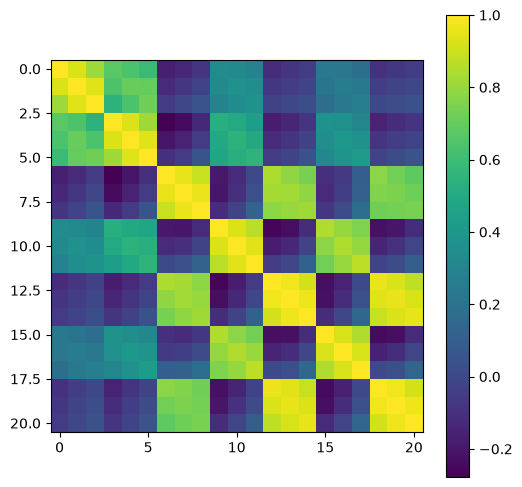

In [166]:
plt.figure(figsize=(6, 6))
plt.imshow(factors_df.corr().values, cmap='viridis', interpolation='nearest')
plt.colorbar()

In [240]:
# ====== 第一步：VIF 筛选 ======
factors_vif = prune_by_vif(factors_df, threshold=5.0)
print(f"VIF 筛选：{factors_df.shape[1]} 列 → {factors_vif.shape[1]} 列")
print(f"保留因子：{list(factors_vif.columns)}")

VIF 筛选：27 列 → 17 列
保留因子：['SH.000986_mom_10d', 'SH.000990_mom_10d', 'SH.000991_mom_10d', 'SH.000993_mom_10d', 'SZ.399244_mom_10d', 'SZ.399967_mom_10d', 'SH.000986_mom_20d', 'SH.000990_mom_20d', 'SZ.399967_mom_20d', 'SZ.399995_mom_20d', 'SH.000034_mom_60d', 'SH.000986_mom_60d', 'SH.000990_mom_60d', 'SH.000991_mom_60d', 'SH.000993_mom_60d', 'SZ.399244_mom_60d', 'SZ.399967_mom_60d']


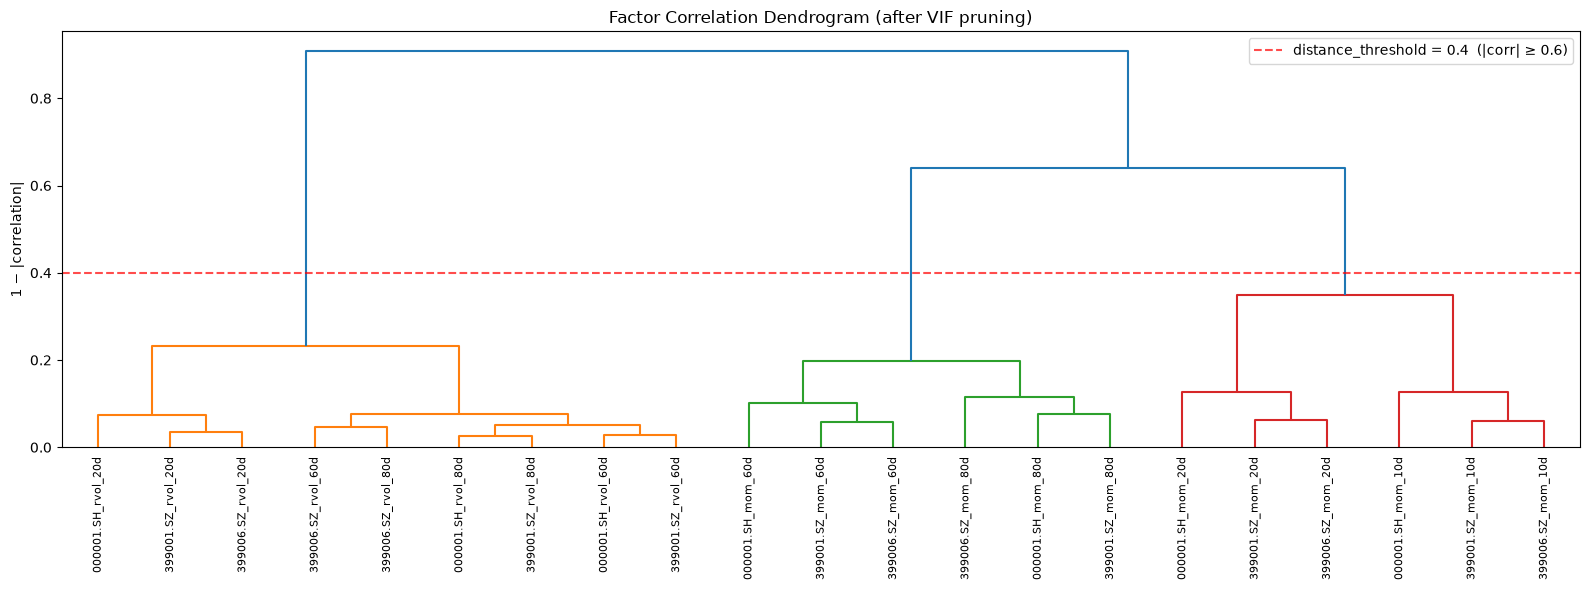

In [167]:
# ====== 第二步：sklearn 层次聚类 + 树状图 ======
corr = factors_df.corr().abs()
dist = (1 - corr).values

# sklearn 聚类：距离 > 0.5 不合并，等价于 |corr| < 0.5 的不归一组
threshold = 0.4
agg = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=threshold,
    metric='precomputed',
    linkage='average',
)
labels = agg.fit_predict(dist)

# 树状图（scipy 仅用于画图，不参与聚类逻辑）
Z = linkage(squareform(dist), method='average')
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, labels=factors_df.columns, ax=ax, leaf_rotation=90, leaf_font_size=8)
ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label=f'distance_threshold = {threshold}  (|corr| ≥ {1 - threshold})')
ax.set_ylabel('1 − |correlation|')
ax.set_title('Factor Correlation Dendrogram (after VIF pruning)')
ax.legend()
plt.tight_layout()
plt.show()

In [217]:

# ====== 第三步：分组列表，人工选代表 ======
from collections import defaultdict
grouped = defaultdict(list)
for col, label in zip(factors_vif.columns, labels):
    grouped[label].append(col)

print(f"\n===== |corr| ≥ 0.5 归为一簇，共 {len(grouped)} 组 =====")
for label in sorted(grouped):
    members = grouped[label]
    if len(members) == 1:
        print(f"\n单因子（无需选择）: {members[0]}")
    else:
        print(f"\n组 {label}（{len(members)} 个因子，请人工选一个）:")
        for m in members:
            print(f"  - {m}")


===== |corr| ≥ 0.5 归为一簇，共 1 组 =====

组 0（18 个因子，请人工选一个）:
  - SH.000986_mom_10d
  - SH.000987_mom_10d
  - SH.000990_mom_10d
  - SH.000991_mom_10d
  - SH.000993_mom_10d
  - SZ.399244_mom_10d
  - SZ.399967_mom_10d
  - SH.000986_mom_20d
  - SH.000990_mom_20d
  - SZ.399967_mom_20d
  - SZ.399995_mom_20d
  - SZ.399995_rvol_20d
  - SH.000986_mom_60d
  - SH.000990_mom_60d
  - SH.000991_mom_60d
  - SH.000993_mom_60d
  - SZ.399244_mom_60d
  - SZ.399967_mom_60d


In [168]:
# ====== 第三步：分组列表，人工选代表 ======
from collections import defaultdict
grouped = defaultdict(list)
for col, label in zip(factors_df.columns, labels):
    grouped[label].append(col)

# ----- 簇内选 medoid：到同簇其他成员平均距离最小的因子 -----
def select_medoid(members, dist_matrix, col_index):
    """从 members 中选出到其他成员平均距离最小的因子。"""
    if len(members) == 1:
        return members[0]
    idxs = [col_index[m] for m in members]
    sub_dist = dist_matrix[np.ix_(idxs, idxs)]
    avg_dist = sub_dist.mean(axis=1)
    best = members[np.argmin(avg_dist)]
    return best

col_index = {c: i for i, c in enumerate(factors_df.columns)}

selected_factors = []
for label in sorted(set(labels)):
    members = [c for c, l in zip(factors_df.columns, labels) if l == label]
    rep = select_medoid(members, dist, col_index)
    selected_factors.append(rep)

print(f"Selected {len(selected_factors)} factors:")
for f in selected_factors:
    print(f"  {f}")

Selected 3 factors:
  399001.SZ_mom_10d
  399001.SZ_rvol_60d
  399001.SZ_mom_60d


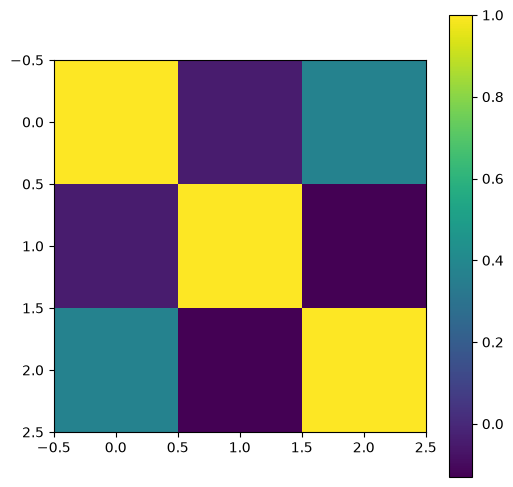

In [169]:
plt.figure(figsize=(6, 6))
plt.imshow(factors_df[selected_factors].corr().values, cmap='viridis', interpolation='nearest')
plt.colorbar()

## 为聚类准备数据


In [170]:
scaler = StandardScaler()
factors_scaled = scaler.fit_transform(factors_df[selected_factors].copy())

print(
    f"Factor data: {len(factors_df)} days ({factors_df.index.min().year} to {factors_df.index.max().year})"
)

Factor data: 2716 days (2015 to 2026)


## 使用 GMM 进行状态识别


In [171]:
n_regimes_list = [2, 3, 4, 5, 6]

# 拟合 GMM 网格
gmm_grid = fit_gmm_grid(factors_scaled, n_regimes_list)

# 同时拟合 K-Means 以作比较
kmeans_results = {}
for n in n_regimes_list:
    kmeans = KMeans(n_clusters=n, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(factors_scaled)
    kmeans_results[n] = (kmeans, labels)

# 以 DataFrame 形式报告模型选择准则（BIC/AIC 越低越好；轮廓系数越高越好）。
selection_df = pd.DataFrame(
    {
        "n": n_regimes_list,
        "BIC": [gmm_grid[n].bic for n in n_regimes_list],
        "AIC": [gmm_grid[n].aic for n in n_regimes_list],
        "Silhouette (GMM)": [gmm_grid[n].silhouette for n in n_regimes_list],
        "Silhouette (K-Means)": [
            silhouette_score(factors_scaled, kmeans_results[n][1]) for n in n_regimes_list
        ],
    }
).set_index("n")
selection_df.style.format(
    {
        "BIC": "{:.1f}",
        "AIC": "{:.1f}",
        "Silhouette (GMM)": "{:.3f}",
        "Silhouette (K-Means)": "{:.3f}",
    }
)

,BIC,AIC,Silhouette (GMM),Silhouette (K-Means)
n,,,,
2,19757.6,19645.4,0.422,0.378
3,19425.3,19254.0,0.391,0.374
4,18965.9,18735.5,0.215,0.278
5,18663.1,18373.6,0.115,0.285
6,18493.3,18144.8,0.132,0.277


**解读**：BIC 在 K=2 时最小（26,170），轮廓系数在 K=2 时最大（0.27）；AIC 持续下降直到 K=6（24,930）。BIC 对模型复杂度的惩罚比 AIC 更重，当目标是可解释性而非最大似然时，它是标准选择。我们采用 K=2——一个风险偏好（Risk-On）/风险规避（Risk-Off）的划分，BIC 和轮廓系数在该 1927–2024 面板上均选择此结果。

轮廓系数在 K≥4 时变为负值（K=4 时为 −0.02，K=5 和 K=6 时接近零），表明更高的聚类数量会产生重叠、分离度差的状态。


## 模型选择可视化

下图展示了不同聚类数量下的 BIC、AIC 和轮廓系数。注意 y 轴已缩放以突出模型之间的差异。


In [172]:
metrics = {
    "BIC": [gmm_grid[n].bic for n in n_regimes_list],
    "AIC": [gmm_grid[n].aic for n in n_regimes_list],
    "Silhouette": [gmm_grid[n].silhouette for n in n_regimes_list],
}

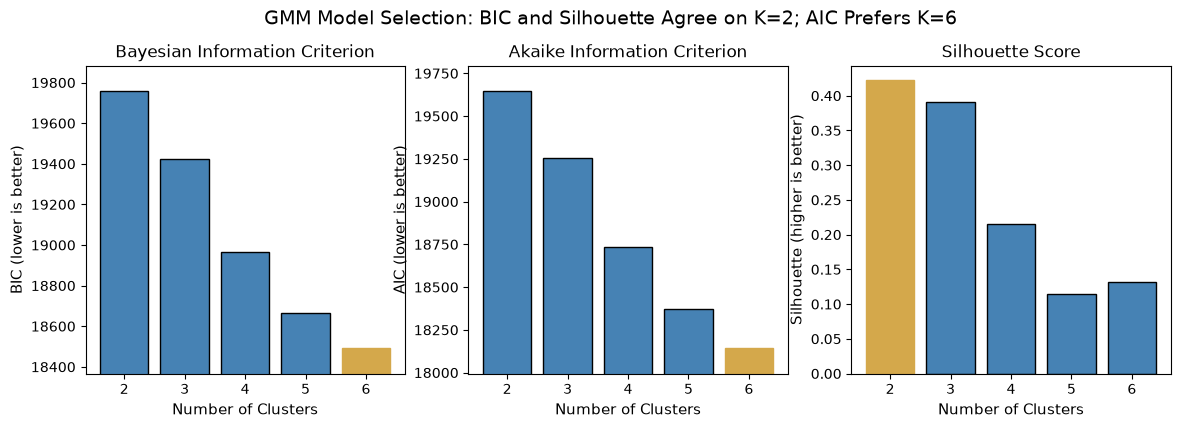

In [173]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# BIC（越低越好）- 缩放 y 轴
ax = axes[0]
bars = ax.bar(n_regimes_list, metrics["BIC"], color="steelblue", edgecolor="black")
best_idx = np.argmin(metrics["BIC"])
bars[best_idx].set_color("#D4A84B")
ax.set_xlabel("Number of Clusters", fontsize=11)
ax.set_ylabel("BIC (lower is better)", fontsize=11)
ax.set_title("Bayesian Information Criterion", fontsize=12)
ax.set_xticks(n_regimes_list)
# 缩放 y 轴以更清晰地显示差异
bic_min, bic_max = min(metrics["BIC"]), max(metrics["BIC"])
bic_range = bic_max - bic_min
ax.set_ylim(bic_min - 0.1 * bic_range, bic_max + 0.1 * bic_range)

# AIC（越低越好）- 缩放 y 轴
ax = axes[1]
bars = ax.bar(n_regimes_list, metrics["AIC"], color="steelblue", edgecolor="black")
best_idx = np.argmin(metrics["AIC"])
bars[best_idx].set_color("#D4A84B")
ax.set_xlabel("Number of Clusters", fontsize=11)
ax.set_ylabel("AIC (lower is better)", fontsize=11)
ax.set_title("Akaike Information Criterion", fontsize=12)
ax.set_xticks(n_regimes_list)
# 缩放 y 轴以更清晰地显示差异
aic_min, aic_max = min(metrics["AIC"]), max(metrics["AIC"])
aic_range = aic_max - aic_min
ax.set_ylim(aic_min - 0.1 * aic_range, aic_max + 0.1 * aic_range)

# 轮廓系数（越高越好）
ax = axes[2]
bars = ax.bar(n_regimes_list, metrics["Silhouette"], color="steelblue", edgecolor="black")
best_idx = np.argmax(metrics["Silhouette"])
bars[best_idx].set_color("#D4A84B")
ax.set_xlabel("Number of Clusters", fontsize=11)
ax.set_ylabel("Silhouette (higher is better)", fontsize=11)
ax.set_title("Silhouette Score", fontsize=12)
ax.set_xticks(n_regimes_list)

fig.suptitle(
    "GMM Model Selection: BIC and Silhouette Agree on K=2; AIC Prefers K=6",
    fontsize=14,
    y=1.02,
)
plt.show()

## 状态时间线可视化


In [28]:
def plot_regime_timeline(
    labels: np.ndarray,
    dates: pd.Index,
    n_regimes: int,
    title: str,
    ax: Axes | None = None,
) -> Axes:
    """将状态分配绘制为时间线热力图（每个状态一行）。"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 0.8 * n_regimes + 1))

    years = [pd.Timestamp(ts).year for ts in dates]

    # 创建二值矩阵：(n_regimes x n_months)
    regime_matrix = np.zeros((n_regimes, len(labels)))
    for i, label in enumerate(labels):
        regime_matrix[label, i] = 1

    # 将每个状态绘制为泳道。origin='lower' 使数据行 k 锚定在
    # y=k 处（与下方的 "Regime k+1" y 轴刻度标签对应）。
    ax.imshow(
        regime_matrix,
        aspect="auto",
        cmap="Blues",
        vmin=0,
        vmax=1,
        extent=(0, len(labels), -0.5, n_regimes - 0.5),
        interpolation="nearest",
        origin="lower",
    )

    # Y 轴：状态标签
    ax.set_yticks(range(n_regimes))
    ax.set_yticklabels([f"Regime {i + 1}" for i in range(n_regimes)], fontsize=10)

    # X 轴：1年刻度
    year_ticks = []
    year_labels_list = []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 1 == 0:
                year_ticks.append(j)
                year_labels_list.append(str(year))

    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels_list, fontsize=9)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(title, fontsize=12)

    # 在状态之间添加水平网格线
    for i in range(1, n_regimes):
        ax.axhline(y=i - 0.5, color="white", linewidth=2)

    return ax

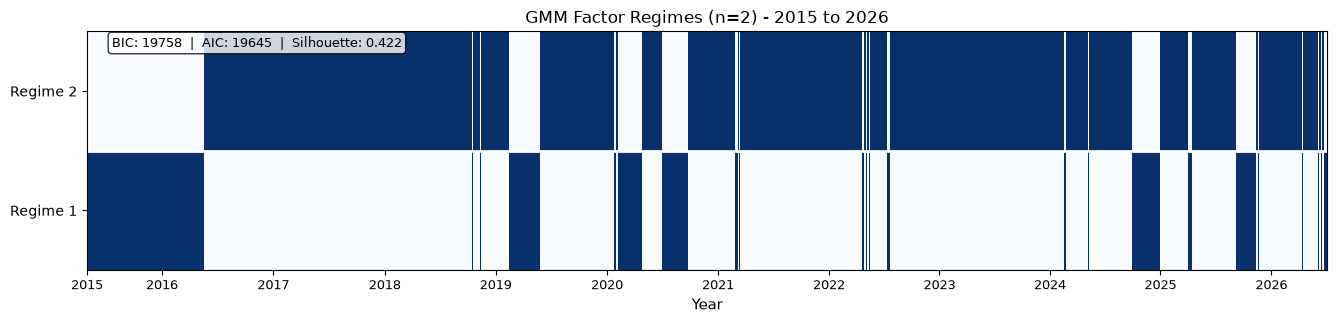

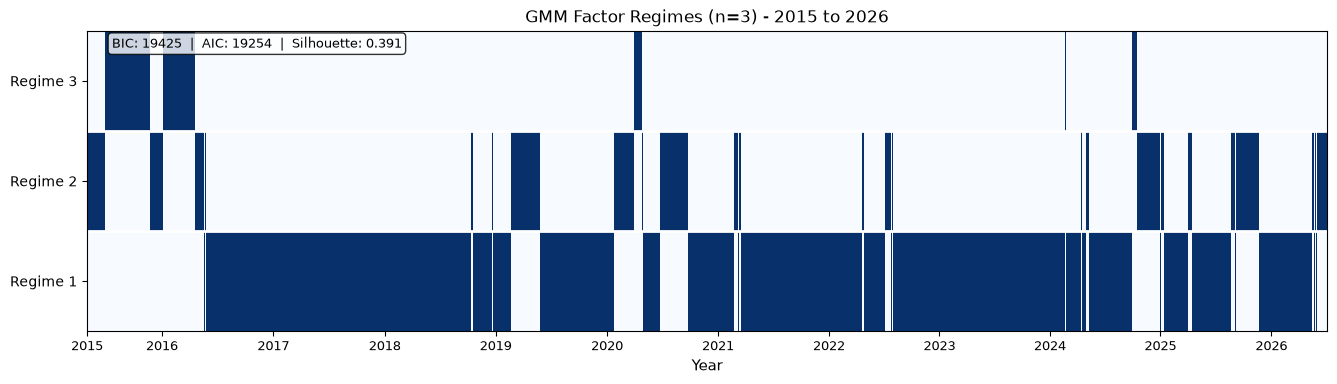

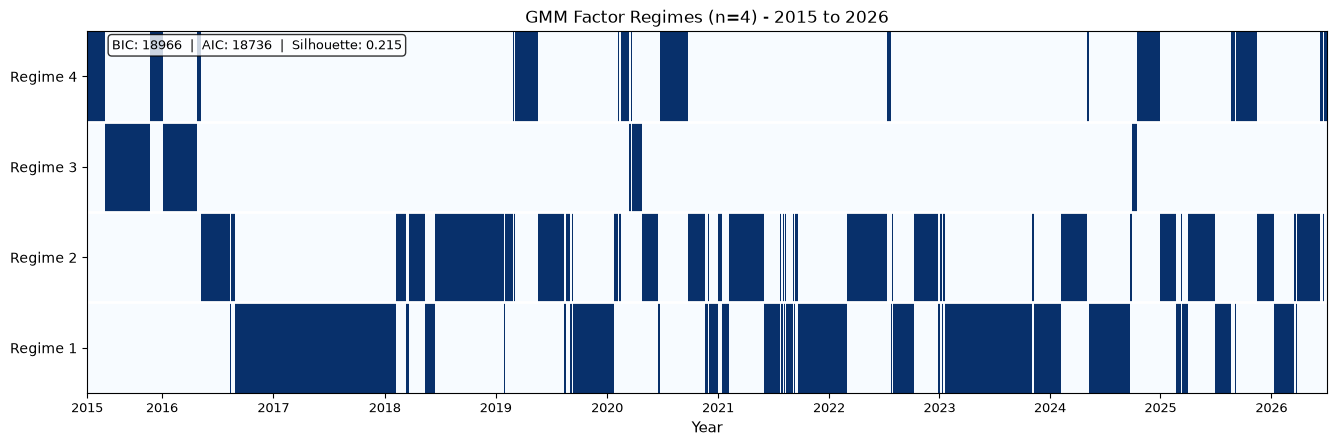

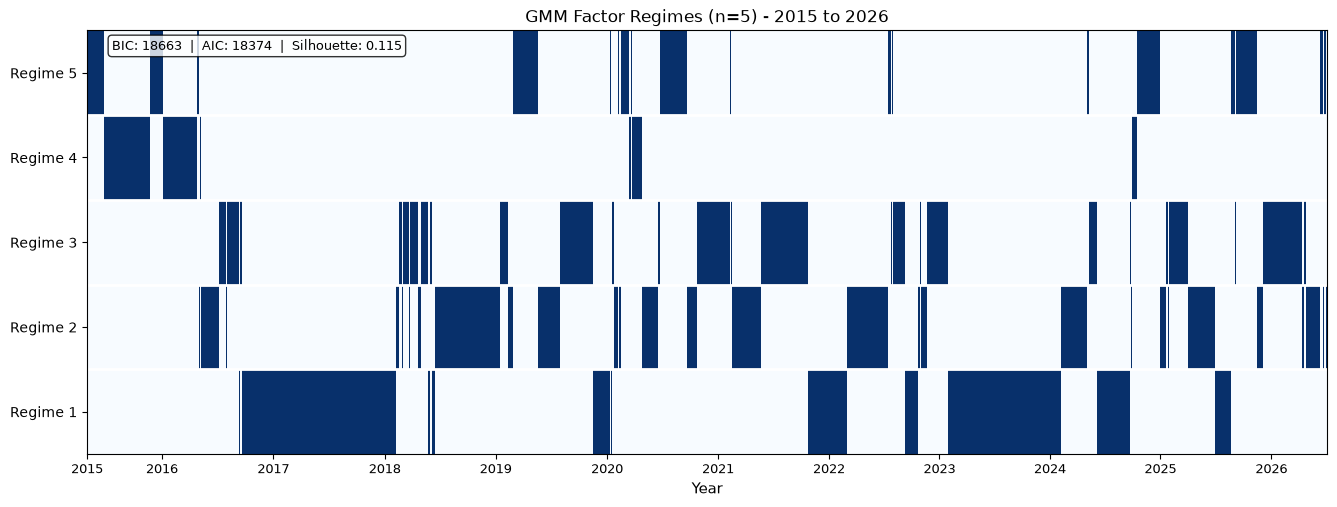

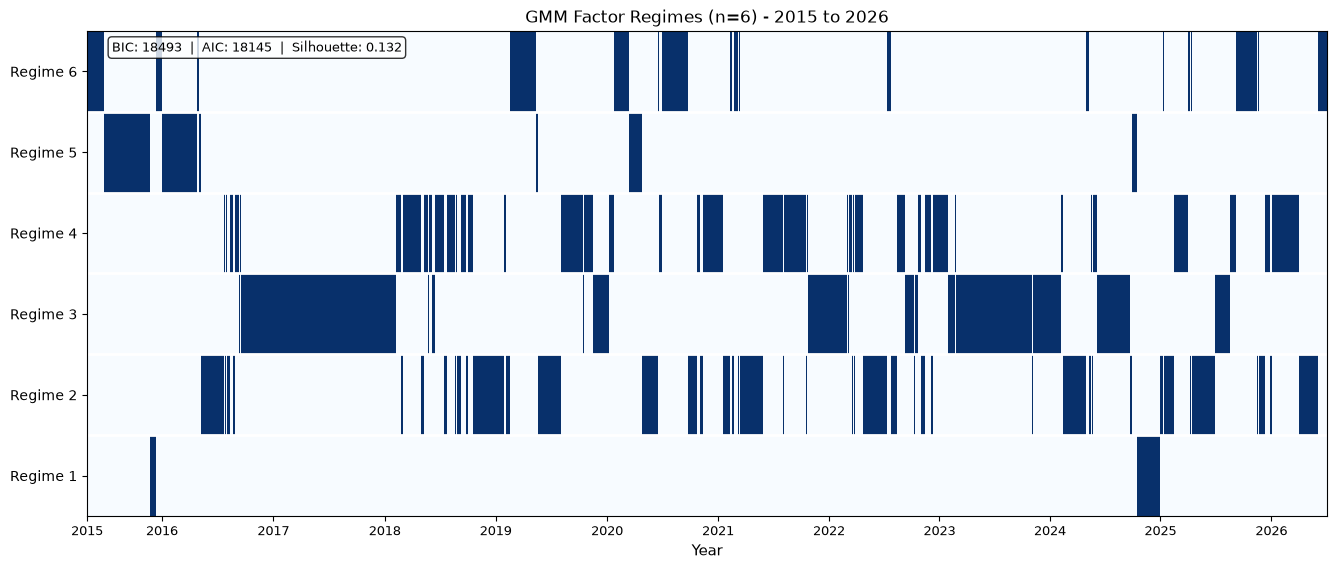

In [174]:
# 为每种聚类数量创建泳道图
start_year = factors_df.index.min().year
end_year = factors_df.index.max().year

for n in n_regimes_list:
    fig, ax = plt.subplots(figsize=(16, 0.8 * n + 1.5))
    labels = gmm_grid[n].labels

    plot_regime_timeline(
        labels=labels,
        dates=factors_df.index,
        n_regimes=n,
        title=f"GMM Factor Regimes (n={n}) - {start_year} to {end_year}",
        ax=ax,
    )

    # 添加指标标注
    bic = gmm_grid[n].bic
    aic = gmm_grid[n].aic
    sil = gmm_grid[n].silhouette
    ax.text(
        0.02,
        0.98,
        f"BIC: {bic:.0f}  |  AIC: {aic:.0f}  |  Silhouette: {sil:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    plt.show()

## 双状态视角：Risk-On 与 Risk-Off

双状态划分将因子普遍跑赢的时期与普遍跑输的时期分开。这正是上面 BIC 和轮廓系数选择的模型；下面的分析从经验上刻画这两种状态。


In [32]:
hs300_pl = xt.fetch_batch_ohlcv(["399300.SZ"],"2005-01-01", "2026-07-08")

2026-08-11 00:07:46 [info     ] Batch fetching from xtdata     end=20260708 period=1d start=20050101 total_symbols=1
2026-08-11 00:07:46 [info     ] Batch fetch complete           failed_symbols=0 successful_symbols=1 total_rows=5223


In [33]:
hs300_pl = hs300_pl.with_columns((pl.col("close") / pl.col("preClose")).log().alias("log_ret"))
hs300_df = hs300_pl.to_pandas().set_index('timestamp')

In [36]:
# 用于标注的历史事件
historical_events = {
    1929: ("Great Crash", "top"),
    1937: ("Recession", "bottom"),
    1973: ("Oil Crisis", "top"),
    1987: ("Black Monday", "bottom"),
    2000: ("Dot-com", "top"),
    2008: ("GFC", "bottom"),
    2020: ("COVID", "top"),
}

# 使用 n=2 以获得更清晰、更稳定的状态识别
n_regimes_book = 3
labels_2 = gmm_grid[n_regimes_book].labels

# 事后标注以增强可解释性（非预测性）
common_dates = hs300_df.index.intersection(factors_df.index)
aligned_returns = hs300_df.loc[common_dates, "log_ret"]
aligned_labels = labels_2[factors_df.index.isin(common_dates)]
regime_mean_ret = aligned_returns.groupby(aligned_labels).mean()
good_regime = regime_mean_ret.idxmax()
bad_regime = 1 - good_regime

### Risk-On 与 Risk-Off 状态时间线

泳道面板，展示状态分配以及累计股票收益率。


In [ ]:
def plot_two_regime_view():
    """创建双状态模型的泳道图与累计收益率图。"""
    # 创建带泳道面板和累计收益率的图形
    fig, axes = plt.subplots(2, 1, figsize=(14, 5.5), height_ratios=[1, 2], sharex=True)

    # 面板 1：状态泳道
    ax1 = axes[0]

    # 创建二值矩阵：第 0 行 = Risk-Off，第 1 行 = Risk-On
    regime_matrix = np.zeros((2, len(labels_2)))
    for i, label in enumerate(labels_2):
        if label == good_regime:
            regime_matrix[1, i] = 1  # Risk-On row
        else:
            regime_matrix[0, i] = 1  # Risk-Off row

    # 为泳道使用灰度友好的颜色。origin='lower' 使数据
    # 第 0 行（Risk-Off）锚定在坐标轴底部，第 1 行（Risk-On）
    # 在顶部，与下方的 y 轴刻度标签对应。
    cmap_swim = ListedColormap(["white", "#2d2d2d"])
    ax1.imshow(
        regime_matrix,
        aspect="auto",
        cmap=cmap_swim,
        vmin=0,
        vmax=1,
        extent=[0, len(labels_2), -0.5, 1.5],
        interpolation="nearest",
        origin="lower",
    )

    # Y 轴：状态标签
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(["Risk-Off", "Risk-On"], fontsize=10)
    ax1.axhline(y=0.5, color="gray", linewidth=1.5)

    # X 轴设置
    years = [pd.Timestamp(ts).year for ts in factors_df.index]
    decade_ticks = []
    decade_labels = []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 10 == 0:
                decade_ticks.append(j)
                decade_labels.append(str(year))

    # 添加历史事件标记（黑色标签，而非红色）
    for event_year, (event_label, pos) in historical_events.items():
        try:
            idx = next(j for j, y in enumerate(years) if y == event_year)
            ax1.axvline(x=idx, color="black", linestyle="-", alpha=0.6, linewidth=1.5)
            y_pos = 1.7 if pos == "top" else -0.7
            va = "bottom" if pos == "top" else "top"
            ax1.annotate(
                event_label,
                xy=(idx, y_pos),
                xycoords=("data", "data"),
                ha="center",
                va=va,
                fontsize=8,
                color="black",
                fontweight="bold",
            )
        except StopIteration:
            pass

    ax1.set_xlim(0, len(labels_2))
    ax1.set_ylim(-0.5, 1.5)

    # 面板 2：按状态着色的累计股票收益率
    ax2 = axes[1]
    #equity_returns = factors_df["Equity indices Market"]
    #cum_returns = (1 + equity_returns).cumprod()
    # 对数收益率
    cum_returns = aligned_returns.cumsum()
    
    # 按状态着色绘制
    for i in range(len(cum_returns) - 1):
        color = "#2196F3" if aligned_labels[i] == good_regime else "#F44336"
        ax2.plot(
            [i, i + 1], [cum_returns.iloc[i], cum_returns.iloc[i + 1]], color=color, linewidth=1.2
        )

    #ax2.set_yscale("log")
    ax2.set_ylabel("Cumulative Log Return", fontsize=10)
    ax2.set_xlabel("Year", fontsize=10)
    ax2.set_xticks(decade_ticks)
    ax2.set_xticklabels(decade_labels, fontsize=9)
    ax2.grid(True, alpha=0.3)

    # 标注（还原为真实收益倍数）
    final_val = np.exp(cum_returns.iloc[-1])
    ax2.annotate(
        f"${final_val:.0f}",
        xy=(len(cum_returns) - 1, cum_returns.iloc[-1]),
        xytext=(10, 0),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )
    ax2.annotate(
        "$1 invested in 1927",
        xy=(0, 1),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        style="italic",
    )

    fig.suptitle(
        f"Market Regimes: Risk-On vs Risk-Off ({start_year}-{end_year})",
        fontsize=12,
        fontweight="bold",
        y=1.02,
    )

    plt.show()

In [34]:
def plot_regime_view(n_regimes=None):
    """创建多状态模型的泳道图与累计收益率图。"""
    if n_regimes is None:
        n_regimes = n_regimes_book

    labels = gmm_grid[n_regimes].labels

    # 对齐时间轴
    common_dates = hs300_df.index.intersection(factors_df.index)
    cum_returns = hs300_df.loc[common_dates, "log_ret"].cumsum()
    aligned_labels = labels[factors_df.index.isin(common_dates)]

    # 按收益率排序确定 regime 命名
    regime_ret = hs300_df.loc[common_dates, "log_ret"].groupby(aligned_labels).mean()
    sorted_regimes = regime_ret.sort_values().index.tolist()  # 最差 → 最好

    # 颜色映射
    if n_regimes == 2:
        colors = ["#F44336", "#2196F3"]
    elif n_regimes == 3:
        colors = ["#F44336", "#FF9800", "#2196F3"]
    elif n_regimes == 4:
        colors = ["#F44336", "#FF9800", "#4CAF50", "#2196F3"]
    else:
        cmap = plt.cm.RdYlGn
        colors = [cmap(i / (n_regimes - 1)) for i in range(n_regimes)]

    label_names = {sorted_regimes[i]: f"Regime {i + 1}" for i in range(n_regimes)}

    fig, axes = plt.subplots(2, 1, figsize=(14, 2 + n_regimes * 0.8), height_ratios=[n_regimes, 3], sharex=True)

    # 面板 1：状态泳道
    ax1 = axes[0]
    regime_matrix = np.zeros((n_regimes, len(labels)))
    for i, label in enumerate(labels):
        regime_matrix[label, i] = 1

    ax1.imshow(
        regime_matrix,
        aspect="auto",
        cmap=ListedColormap(["white", "#2d2d2d"]),
        vmin=0, vmax=1,
        extent=[0, len(labels), -0.5, n_regimes - 0.5],
        interpolation="nearest",
        origin="lower",
    )
    ax1.set_yticks(range(n_regimes))
    ax1.set_yticklabels([label_names[r] for r in sorted_regimes], fontsize=10)
    for i in range(1, n_regimes):
        ax1.axhline(y=i - 0.5, color="gray", linewidth=1)

    # X 轴
    years = [pd.Timestamp(ts).year for ts in factors_df.index]
    decade_ticks, decade_labels_list = [], []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 1 == 0:
                decade_ticks.append(j)
                decade_labels_list.append(str(year))

    for event_year, (event_label, pos) in historical_events.items():
        try:
            idx = next(j for j, y in enumerate(years) if y == event_year)
            ax1.axvline(x=idx, color="black", linestyle="-", alpha=0.6, linewidth=1.5)
            y_pos = n_regimes + 0.2 if pos == "top" else -1.2
            va = "bottom" if pos == "top" else "top"
            ax1.annotate(event_label, xy=(idx, y_pos), ha="center", va=va,
                         fontsize=8, color="black", fontweight="bold")
        except StopIteration:
            pass

    ax1.set_xlim(0, len(labels))
    ax1.set_ylim(-0.5, n_regimes - 0.5)

    # 面板 2：累计收益率着色
    ax2 = axes[1]
    for i in range(len(cum_returns) - 1):
        r = sorted_regimes.index(aligned_labels[i])
        ax2.plot([i, i + 1], [cum_returns.iloc[i], cum_returns.iloc[i + 1]],
                 color=colors[r], linewidth=1.2)

    ax2.set_ylabel("Cumulative Log Return", fontsize=10)
    ax2.set_xlabel("Year", fontsize=10)
    ax2.set_xticks(decade_ticks)
    ax2.set_xticklabels(decade_labels_list, fontsize=9)
    ax2.grid(True, alpha=0.3)

    final_val = np.exp(cum_returns.iloc[-1])
    ax2.annotate(f"${final_val:.0f}", xy=(len(cum_returns) - 1, cum_returns.iloc[-1]),
                 xytext=(10, 0), textcoords="offset points", fontsize=10, fontweight="bold")

    fig.suptitle(f"Market Regimes (n={n_regimes})  {start_year}-{end_year}",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

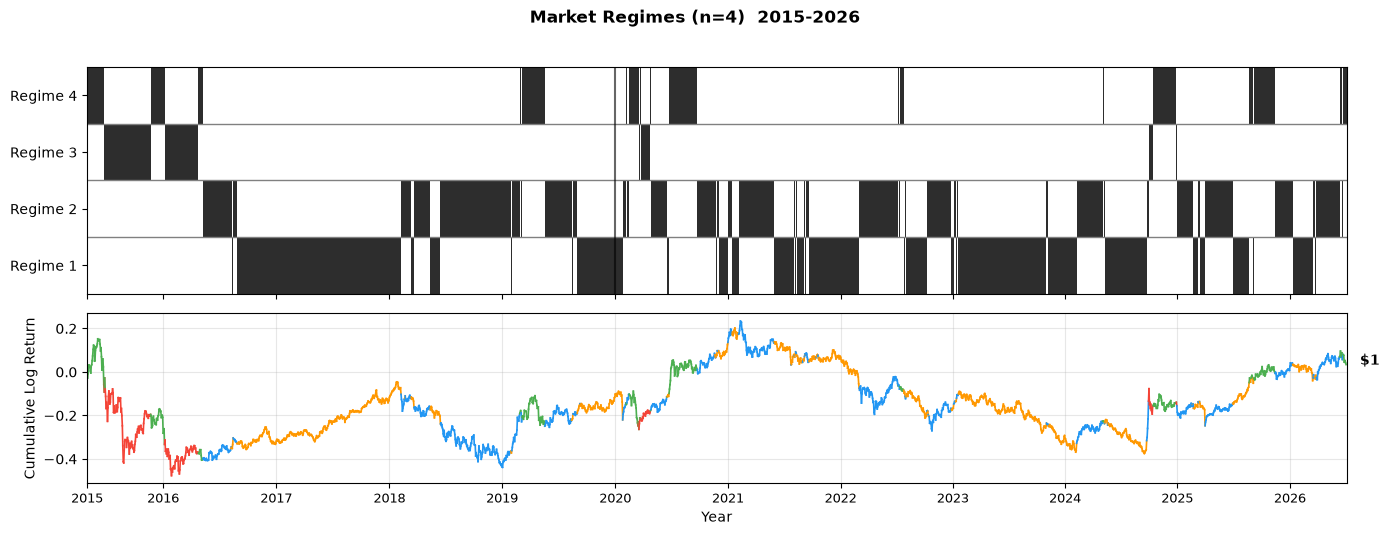

In [175]:
plot_regime_view(4)

## 各状态下的波动率

一个关键问题：不同状态之间的波动率是否有显著差异？如果 Risk-Off 时期的波动率更高，则验证了将状态识别用于风险管理的有效性。

### 波动率状态图

状态带与滚动波动率，展示风险环境的差异。


In [40]:
def plot_volatility_by_regime(n_regimes=None):
    if n_regimes is None:
        n_regimes = n_regimes_book
    labels = gmm_grid[n_regimes].labels
    n = n_regimes

    # 按收益率排序
    common_dates = hs300_df.index.intersection(factors_df.index)
    aligned_labels = labels[factors_df.index.isin(common_dates)]
    aligned_ret = hs300_df.loc[common_dates, "log_ret"]
    sorted_regimes = aligned_ret.groupby(aligned_labels).mean().sort_values().index.tolist()

    # 颜色
    regime_colors = {0: ["#F44336", "#2196F3"],
                     1: ["#F44336", "#FF9800", "#2196F3"],
                     2: ["#F44336", "#FF9800", "#4CAF50", "#2196F3"]}
    colors = regime_colors.get(n - 2, [plt.cm.RdYlGn(i / (n - 1)) for i in range(n)])

    rolling_vol = hs300_df.loc[:, "log_ret"].rolling(20).std()

    fig, axes = plt.subplots(2, 1, figsize=(14, 2 + n * 0.8), height_ratios=[n, 3], sharex=True)

        # 面板 1：泳道（按 sorted_regimes 重排行）
    ax1 = axes[0]
    regime_matrix = np.zeros((n, len(labels)))
    for i, lbl in enumerate(labels):
        row = sorted_regimes.index(lbl)
        regime_matrix[row, i] = 1
    ax1.imshow(regime_matrix, aspect="auto", cmap=ListedColormap(["white", "#2d2d2d"]),
               vmin=0, vmax=1, extent=[0, len(labels), -0.5, n - 0.5], interpolation="nearest", origin="lower")
    ax1.set_yticks(range(n))
    ax1.set_yticklabels([f"Regime {r + 1}" for r in sorted_regimes], fontsize=9)
    for i in range(1, n):
        ax1.axhline(y=i - 0.5, color="gray", linewidth=1)
    ax1.set_title("Regime Classification", fontsize=10)

    # 面板 2：波动率
    ax2 = axes[1]
    vol_aligned = rolling_vol.loc[common_dates]
    for i in range(len(vol_aligned) - 1):
        if pd.notna(vol_aligned.iloc[i]) and pd.notna(vol_aligned.iloc[i + 1]):
            r = sorted_regimes.index(aligned_labels[i])
            ax2.plot([i, i + 1], [vol_aligned.iloc[i] * 100, vol_aligned.iloc[i + 1] * 100],
                     color=colors[r], linewidth=1.2)

    for r in sorted_regimes:
        mask = aligned_labels == r
        mean_vol = vol_aligned[mask].mean()
        ax2.axhline(mean_vol * 100, color=colors[sorted_regimes.index(r)], linestyle="--", linewidth=2,
                     label=f"Regime {r + 1} avg: {mean_vol * 100:.1f}%")
    ax2.legend(loc="upper right", fontsize=9)

    years = [pd.Timestamp(ts).year for ts in factors_df.index]
    decade_ticks, decade_labels_list = [], []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 1 == 0:
                decade_ticks.append(j)
                decade_labels_list.append(str(year))
    ax2.set_xticks(decade_ticks)
    ax2.set_xticklabels(decade_labels_list, fontsize=9)
    ax2.set_xlabel("Year", fontsize=10)
    ax2.set_ylabel("Rolling 20-Day Volatility (%)", fontsize=10)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"Market Volatility by Regime (n={n})  {start_year}-{end_year}",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    vol_by_regime = []
    for r in sorted_regimes:
        mask = aligned_labels == r
        v = vol_aligned[mask].dropna()
        vol_by_regime.append({"Regime": f"Regime {r + 1}", "Mean Vol": v.mean(), "Median Vol": v.median(), "Max Vol": v.max()})
        vol_df = pd.DataFrame(vol_by_regime).set_index("Regime")

    return vol_df.style.format({"Mean Vol": "{:.4f}", "Median Vol": "{:.4f}", "Max Vol": "{:.4f}"})

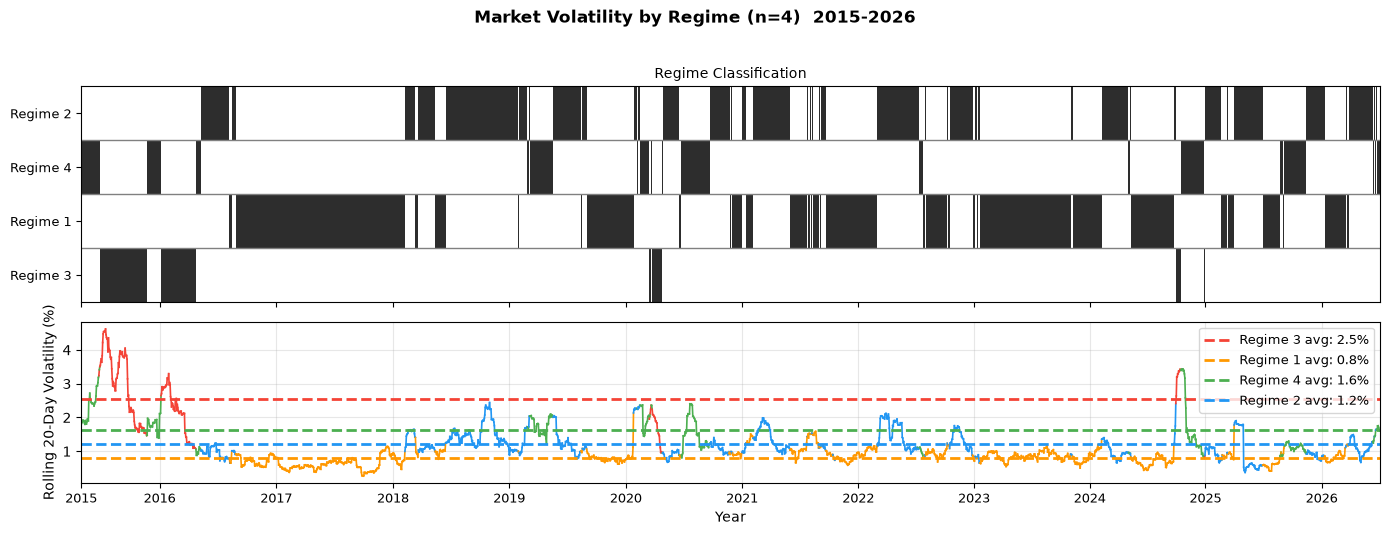

,Mean Vol,Median Vol,Max Vol
Regime,,,
Regime 3,0.0255,0.0230,0.0462
Regime 1,0.0079,0.0079,0.0163
Regime 4,0.0163,0.0152,0.0343
Regime 2,0.0122,0.0112,0.0244


In [176]:
vol_summary = plot_volatility_by_regime(4)
vol_summary

## 各状态下的因子表现


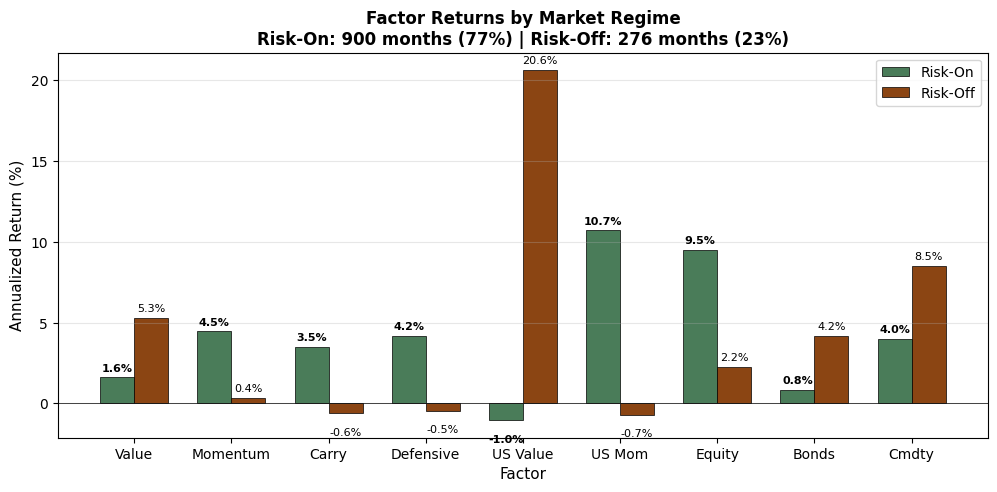

Period: 1927-2024 (1176 months)
Regime distribution: Risk-On 900 (76.5%), Risk-Off 276 (23.5%)


,Risk-Off (%),Risk-On (%)
Value,5.3,1.6
Momentum,0.4,4.5
Equity,2.2,9.5
Bonds,4.2,0.8
Carry,-0.6,3.5
Defensive,-0.5,4.2


In [19]:
def plot_factor_returns_by_regime():
    """比较 Risk-On 与 Risk-Off 状态下因子的年化收益率。"""
    # 按状态计算因子平均收益率
    regime_labels_2 = pd.Series(labels_2, index=factors_df.index, name="regime")
    factor_by_regime = factors_df.copy()
    factor_by_regime["regime"] = regime_labels_2

    # 各状态的平均收益率（年化）
    regime_means = factor_by_regime.groupby("regime").mean() * 12
    regime_means.index = ["Risk-Off" if i == bad_regime else "Risk-On" for i in regime_means.index]

    # 重命名列以便阅读
    col_renames = {
        "All asset classes Value": "Value",
        "All asset classes Momentum": "Momentum",
        "All asset classes Carry": "Carry",
        "All asset classes Defensive": "Defensive",
        "US Stock Selection Value": "US Value",
        "US Stock Selection Momentum": "US Mom",
        "Equity indices Market": "Equity",
        "Fixed income Market": "Bonds",
        "Commodities Market": "Cmdty",
    }
    regime_means_display = regime_means.rename(columns=col_renames)

    # 创建比较各状态的柱状图
    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(regime_means_display.columns))
    width = 0.35

    bars1 = ax.bar(
        x - width / 2,
        regime_means_display.loc["Risk-On"].values * 100,
        width,
        label="Risk-On",
        color="#4a7c59",
        edgecolor="black",
        linewidth=0.5,
    )
    bars2 = ax.bar(
        x + width / 2,
        regime_means_display.loc["Risk-Off"].values * 100,
        width,
        label="Risk-Off",
        color="#8b4513",
        edgecolor="black",
        linewidth=0.5,
    )

    # 添加数值标签
    for bar, val in zip(bars1, regime_means_display.loc["Risk-On"].values, strict=False):
        height = bar.get_height()
        ax.annotate(
            f"{val * 100:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3 if height >= 0 else -10),
            textcoords="offset points",
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=8,
            fontweight="bold",
        )

    for bar, val in zip(bars2, regime_means_display.loc["Risk-Off"].values, strict=False):
        height = bar.get_height()
        ax.annotate(
            f"{val * 100:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3 if height >= 0 else -10),
            textcoords="offset points",
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=8,
        )

    ax.set_ylabel("Annualized Return (%)", fontsize=11)
    ax.set_xlabel("Factor", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(regime_means_display.columns, fontsize=10)
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    n_on = (labels_2 == good_regime).sum()
    n_off = (labels_2 == bad_regime).sum()
    ax.set_title(
        f"Factor Returns by Market Regime\nRisk-On: {n_on} months ({n_on / len(labels_2) * 100:.0f}%) | Risk-Off: {n_off} months ({n_off / len(labels_2) * 100:.0f}%)",
        fontsize=12,
        fontweight="bold",
    )

    plt.show()

    # 以 DataFrame 形式展示各因子的收益率，便于比较。
    period_label = (
        f"{factors_df.index.min().year}-{factors_df.index.max().year} ({len(factors_df)} months)"
    )
    print(f"Period: {period_label}")
    print(
        f"Regime distribution: Risk-On {n_on} ({n_on / len(labels_2) * 100:.1f}%), "
        f"Risk-Off {n_off} ({n_off / len(labels_2) * 100:.1f}%)"
    )
    key_factors = [
        c
        for c in ["Value", "Momentum", "Equity", "Bonds", "Carry", "Defensive"]
        if c in regime_means_display.columns
    ]
    factor_summary = (regime_means_display[key_factors].T * 100).round(1)
    factor_summary.columns = [f"{c} (%)" for c in factor_summary.columns]
    return factor_summary


factor_summary = plot_factor_returns_by_regime()
factor_summary

**解读**：状态划分揭示了截然不同的因子行为：

- **价值因子是逆周期的**：在 Risk-Off 期间收益率*上升*（+5.3% 对 +1.6%），这与价值溢价补偿困境风险的倾向一致。
- **动量因子是顺周期的**：在 Risk-Off 期间明显减弱（+0.4% 对 +4.5%），反映了动量对剧烈反转的脆弱性。
- **Carry 和 Defensive 在 Risk-Off 期间转负**（−0.6% 和 −0.5%）——这些在平静市场中看似安全的策略在市场恶化时反而亏损。
- **债券在 Risk-Off 期间跑赢**（+4.2% 对 +0.8%），与经典的避险（flight-to-quality）效应一致。

对于组合构建，这表明价值因子和债券在压力时期能提供真正的分散化，而 Carry 和 Defensive 则不能。


## 状态统计

比较 Risk-On 与 Risk-Off 时期的关键指标。


In [42]:
def compute_regime_statistics(n_regimes=None):
    if n_regimes is None:
        n_regimes = n_regimes_book
    labels = gmm_grid[n_regimes].labels

    common_dates = hs300_df.index.intersection(factors_df.index)
    returns = hs300_df.loc[common_dates, "log_ret"]
    aligned_labels = labels[factors_df.index.isin(common_dates)]
    sorted_regimes = returns.groupby(aligned_labels).mean().sort_values().index.tolist()

    regime_stats_list = []
    for r in sorted_regimes:
        mask = aligned_labels == r
        r_ret = returns[mask]
        n_days = mask.sum()
        pct_time = n_days / len(mask) * 100

        mean_ret = r_ret.mean() * 252
        vol = r_ret.std() * np.sqrt(252)
        sharpe = mean_ret / vol if vol > 0 else 0

        cum_log = r_ret.cumsum()
        peak = cum_log.cummax()
        max_dd = (cum_log - peak).min()  # 对数空间，近似即可

        regime_stats_list.append({
            "Regime": f"Regime {r + 1}",
            "Days": n_days,
            "% of Time": pct_time,
            "Ann. Return": mean_ret,
            "Ann. Volatility": vol,
            "Sharpe Ratio": sharpe,
            "Max DD (log)": max_dd,
        })

    regime_stats_df = pd.DataFrame(regime_stats_list).set_index("Regime")
    return regime_stats_df.style.format({
        "% of Time": "{:.1f}%",
        "Ann. Return": "{:+.1%}",
        "Ann. Volatility": "{:.1%}",
        "Sharpe Ratio": "{:.2f}",
        "Max DD (log)": "{:.1%}",
        }
    )

In [177]:
compute_regime_statistics(4)

,Days,% of Time,Ann. Return,Ann. Volatility,Sharpe Ratio,Max DD (log)
Regime,,,,,,
Regime 3,207,7.6%,-29.4%,41.1%,-0.72,-39.1%
Regime 1,1204,44.3%,-7.9%,13.1%,-0.61,-74.1%
Regime 4,345,12.7%,+9.5%,27.9%,0.34,-34.1%
Regime 2,960,35.3%,+13.8%,20.9%,0.66,-34.0%


**解读**：状态划分结果对比鲜明。Risk-On 的夏普比率为 1.11，而 Risk-Off 降至 0.12——在 Risk-Off 期间持有股票敞口本质上是不计回报的风险。Risk-Off 中 −76.9% 的最大回撤反映了大萧条，并强调这些并非温和的调整。

这里的直接波动率比率（2.2 倍）远大于此前报告的滚动窗口均值（1.3 倍）。滚动指标平滑了极端月份，而此计算则捕捉了每个状态内的全部方差。直接指标更能反映组合在 Risk-Off 期间实际经历的情况。


## 状态持续时间分析


In [44]:
def compute_regime_duration(n_regimes=None):
    if n_regimes is None:
        n_regimes = n_regimes_book
    labels = gmm_grid[n_regimes].labels

    common_dates = hs300_df.index.intersection(factors_df.index)
    aligned_ret = hs300_df.loc[common_dates, "log_ret"]
    aligned_labels = labels[factors_df.index.isin(common_dates)]
    sorted_regimes = aligned_ret.groupby(aligned_labels).mean().sort_values().index.tolist()

    durations = {}
    for r in sorted_regimes:
        mask = aligned_labels == r
        runs = []
        cnt = 0
        for v in mask:
            if v:
                cnt += 1
            elif cnt > 0:
                runs.append(cnt)
                cnt = 0
        if cnt > 0:
            runs.append(cnt)
        durations[r] = (np.mean(runs), np.max(runs), len(runs))

    transitions = int(np.sum(np.diff(aligned_labels) != 0))
    avg_days = len(aligned_labels) / transitions if transitions else float("inf")

    duration_list = []
    for r in sorted_regimes:
        duration_list.append({
            "Regime": f"Regime {r + 1}",
            "Avg Duration (days)": durations[r][0],
            "Max Duration (days)": durations[r][1],
            "Episodes": durations[r][2],
        })

    duration_df = pd.DataFrame(duration_list).set_index("Regime")
    print(f"Total regime transitions: {transitions}  (avg {avg_days:.1f} days between switches)")
    return duration_df.style.format({"Avg Duration (days)":"{:.1f}"})

In [178]:
compute_regime_duration(4)

Total regime transitions: 122  (avg 22.3 days between switches)


,Avg Duration (days),Max Duration (days),Episodes
Regime,,,
Regime 3,25.9,98,8
Regime 1,28.7,354,42
Regime 4,15.0,61,23
Regime 2,19.2,152,50


**解读**：在 98 年间有 267 次转换，模型平均大约每 4 个月切换一次状态。Risk-Off 事件持续时间较短（平均约 2 个月）——它们捕捉的是急性压力时期，而非长期熊市。这种频繁切换有实际影响：基于这些信号进行再配置的策略会频繁交易，产生可能侵蚀状态择时收益的交易成本。状态模型更适合*理解*市场动态，而非用于高频战术配置。


## 关键要点

- **BIC 偏好两个状态**：K=2 具有最低的 BIC 和最高的轮廓系数，尽管 AIC 偏好更多聚类。双状态模型提供了最具可解释性和稳定性的状态划分。
- **状态捕捉不同的风险环境**：Risk-Off 的波动率高出 2.2 倍，夏普比率为 0.12（对比 1.11），最大回撤为 −77%。
- **价值因子是逆周期的**：Risk-Off 期间年化 +5.3%，Risk-On 期间 +1.6%。Carry 和 Defensive 尽管名字如此，在 Risk-Off 期间却转为负值。
- **动量因子是顺周期的**：Risk-On 期间 +4.5%，Risk-Off 期间 +0.4%——市场压力时期最弱的因子。
- **状态信号噪声较大**：平均约每 4 个月转换一次，该模型更适合理解因子动态，而非用于战术配置。

**下一步**：`macro_regimes.py` 从风格收益率转向宏观指标（UNRATE、DFF、T10Y2Y、CPIAUCSL），并根据标普 500 的波动率和回撤验证所得聚类。参见第 1 章 §1.4 了解工作流背景。
